# Imbalance-Focused Research: Fake Job Posting Detection

This notebook builds on the completed fake job postings project, but it narrows the research question to class imbalance:

**How does class imbalance affect model evaluation, model selection, threshold choice, and error patterns in fake job posting detection?**

The goal is not to rerun every model from scratch. Instead, this notebook uses the existing cross-validation outputs and error-analysis outputs to examine how different evaluation choices lead to different conclusions.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

RESULTS_DIR = Path('results')
TABLE_DIR = RESULTS_DIR / 'tables'
FIG_DIR = RESULTS_DIR / 'figures'
RESEARCH_DIR = Path('imbalance_research_outputs')
RESEARCH_TABLE_DIR = RESEARCH_DIR / 'tables'
RESEARCH_FIG_DIR = RESEARCH_DIR / 'figures'
for directory in [RESEARCH_DIR, RESEARCH_TABLE_DIR, RESEARCH_FIG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

PRIMARY_DATASET = 'cleaned'

print('Research outputs will be saved to:', RESEARCH_DIR.resolve())

Research outputs will be saved to: C:\Users\patri\OneDrive\Documents\Coding\Python Scripts\fake-job-postings-imbalance-research\imbalance_research_outputs


In [2]:
def savefig(name):
    path = RESEARCH_FIG_DIR / f'{name}.png'
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    return path


def display_and_save(df, name, index=False):
    path = RESEARCH_TABLE_DIR / f'{name}.csv'
    df.to_csv(path, index=index)
    display(df)
    print(f'Saved: {path}')


def metric_label(metric):
    labels = {
        'accuracy_mean': 'Accuracy',
        'balanced_accuracy_mean': 'Balanced Accuracy',
        'roc_auc_mean': 'ROC AUC',
        'average_precision_mean': 'Average Precision',
        'precision_fake_mean': 'Fake Precision',
        'recall_fake_mean': 'Fake Recall',
        'f1_fake_mean': 'Fake F1',
    }
    return labels.get(metric, metric)


def higher_is_better_rank(series):
    return series.rank(method='min', ascending=False).astype(int)

## Load Existing Result Tables

The existing project already ran stratified 5-fold cross-validation. This notebook loads those result files and uses them to analyze metric sensitivity.

In [3]:
dataset_summary = pd.read_csv(TABLE_DIR / 'dataset_summary.csv')
cv_results = pd.read_csv(TABLE_DIR / 'cv_model_comparison.csv')
weighted_results = pd.read_csv(TABLE_DIR / 'weighted_vs_unweighted_linear_models.csv')
threshold_results = pd.read_csv(TABLE_DIR / 'cleaned_threshold_tradeoff_balanced_linear_svm.csv')
error_group_summary = pd.read_csv(TABLE_DIR / 'cleaned_error_group_feature_summary.csv')
binary_error_rates = pd.read_csv(TABLE_DIR / 'cleaned_binary_feature_error_rates.csv')

for df in [cv_results, weighted_results, threshold_results, error_group_summary, binary_error_rates]:
    display(df.head())

,dataset,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,precision_fake_mean,precision_fake_std,recall_fake_mean,recall_fake_std,f1_fake_mean,f1_fake_std
0,cleaned,Linear SVM balanced,0.9858,0.0007,0.9164,0.0093,0.9890,0.0019,0.9140,0.0147,0.8636,0.0095,0.8395,0.0189,0.8512,0.0086
1,cleaned,Logistic Regression balanced,0.9706,0.0031,0.9325,0.0080,0.9884,0.0018,0.8810,0.0182,0.6430,0.0271,0.8903,0.0148,0.7464,0.0211
2,cleaned,Complement Naive Bayes text only,0.8261,0.0111,0.8714,0.0090,0.9539,0.0077,0.7387,0.0398,0.2084,0.0103,0.9215,0.0177,0.3398,0.0138
3,cleaned,Random Forest metadata only,0.9145,0.0046,0.8899,0.0096,0.9651,0.0034,0.7145,0.0245,0.3469,0.0142,0.8626,0.0179,0.4947,0.0160
4,cleaned,Dummy majority baseline,0.9516,0.0001,0.5000,0.0000,0.5000,0.0000,0.0484,0.0001,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


,dataset,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,precision_fake_mean,precision_fake_std,recall_fake_mean,recall_fake_std,f1_fake_mean,f1_fake_std
0,cleaned,Linear SVM unweighted,0.9871,0.0008,0.8951,0.0115,0.9887,0.0020,0.9181,0.0108,0.9301,0.0130,0.7933,0.0236,0.8559,0.0103
1,cleaned,Linear SVM balanced,0.9858,0.0007,0.9164,0.0093,0.9890,0.0019,0.9140,0.0147,0.8636,0.0095,0.8395,0.0189,0.8512,0.0086
2,cleaned,Logistic Regression balanced,0.9706,0.0031,0.9325,0.0080,0.9884,0.0018,0.8810,0.0182,0.6430,0.0271,0.8903,0.0148,0.7464,0.0211
3,cleaned,Logistic Regression unweighted,0.9799,0.0014,0.8157,0.0165,0.9854,0.0025,0.8679,0.0178,0.9292,0.0317,0.6340,0.0337,0.7527,0.0207
4,original,Linear SVM unweighted,0.9872,0.0013,0.8941,0.0152,0.9877,0.0028,0.9168,0.0099,0.9361,0.0109,0.7910,0.0307,0.8570,0.0164


,threshold,flagged_count,flagged_rate,true_positives,false_positives,false_negatives,true_negatives,accuracy,balanced_accuracy,fake_precision,fake_recall,fake_f1
0,-0.9649,2682,0.1500,839,1843,27,15171,0.8954,0.9302,0.3128,0.9688,0.4729
1,-0.7289,1788,0.1000,823,965,43,16049,0.9436,0.9468,0.4603,0.9503,0.6202
2,-0.5056,1341,0.0750,807,534,59,16480,0.9668,0.9502,0.6018,0.9319,0.7313
3,-0.0870,894,0.0500,742,152,124,16862,0.9846,0.9239,0.8300,0.8568,0.8432
4,0.0000,842,0.0471,727,115,139,16899,0.9858,0.9164,0.8634,0.8395,0.8513


,prediction_group,count,model_score_for_fake,title_chars_for_analysis,description_chars_for_analysis,requirements_chars_for_analysis,company_profile_chars_for_analysis,benefits_chars_for_analysis,has_company_logo,has_questions,has_salary_range,has_benefits,has_company_profile,has_department
0,True positive,727,0.938,31.171,1154.351,441.301,245.927,219.926,0.338,0.275,0.248,0.589,0.331,0.398
1,False negative,139,-0.545,28.029,1157.367,470.885,152.252,171.770,0.266,0.360,0.309,0.532,0.273,0.331
2,False positive,115,0.289,26.722,981.330,404.330,121.391,109.696,0.183,0.322,0.330,0.487,0.165,0.348
3,True negative,16899,-1.746,28.433,1222.852,598.780,644.287,209.402,0.823,0.503,0.154,0.598,0.845,0.353


,feature,feature_value,row_count,real_count,fake_count,false_positive_count,false_positive_rate_among_real,false_negative_count,false_negative_rate_among_fake
0,has_company_logo,0,3660,3077,583,94,0.0305,102,0.1750
1,has_company_logo,1,14220,13937,283,21,0.0015,37,0.1307
2,has_questions,0,9088,8472,616,78,0.0092,89,0.1445
3,has_questions,1,8792,8542,250,37,0.0043,50,0.2000
4,has_salary_range,0,15012,14369,643,77,0.0054,96,0.1493


## Class Imbalance Baseline

The dataset contains 17,014 real postings and 866 fake postings. Because fake postings are only about 4.84% of the data, a majority-class model can achieve high accuracy while detecting no fake postings.

,dataset,rows,real_count,fake_count,fake_rate,majority_class_accuracy
0,cleaned,17880,17014,866,4.84%,95.16%
1,original,17880,17014,866,4.84%,95.16%


Saved: imbalance_research_outputs\tables\imbalance_baseline_summary.csv


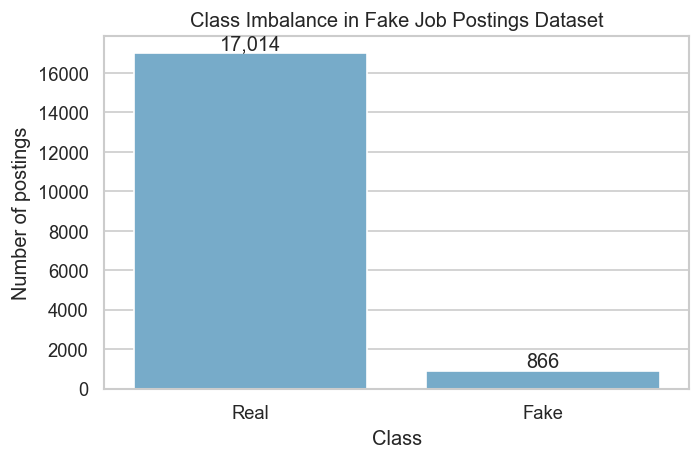

In [4]:
summary = dataset_summary.copy()
summary['fake_rate'] = summary['fake_rate'].astype(float)
summary['majority_class_accuracy'] = 1 - summary['fake_rate']
summary_display = summary[['dataset', 'rows', 'real_count', 'fake_count', 'fake_rate', 'majority_class_accuracy']].copy()
summary_display['fake_rate'] = summary_display['fake_rate'].map(lambda x: f'{x:.2%}')
summary_display['majority_class_accuracy'] = summary_display['majority_class_accuracy'].map(lambda x: f'{x:.2%}')
display_and_save(summary_display, 'imbalance_baseline_summary')

plt.figure(figsize=(6, 4))
plot_df = dataset_summary[dataset_summary['dataset'].eq(PRIMARY_DATASET)].copy()
counts = [int(plot_df['real_count'].iloc[0]), int(plot_df['fake_count'].iloc[0])]
sns.barplot(x=['Real', 'Fake'], y=counts, color='#6aaed6')
plt.title('Class Imbalance in Fake Job Postings Dataset')
plt.ylabel('Number of postings')
plt.xlabel('Class')
for i, val in enumerate(counts):
    plt.text(i, val, f'{val:,}', ha='center', va='bottom')
savefig('class_imbalance_counts')
plt.show()

## Metric-Based Model Selection

This section asks whether the same model is selected as best under every metric. If different metrics select different models, then model selection depends on the evaluation objective.

In [5]:
metric_cols = [
    'accuracy_mean',
    'balanced_accuracy_mean',
    'roc_auc_mean',
    'average_precision_mean',
    'precision_fake_mean',
    'recall_fake_mean',
    'f1_fake_mean',
]

metric_meaning = {
    'accuracy_mean': 'Overall correctness; strongly affected by majority class',
    'balanced_accuracy_mean': 'Average performance across both classes',
    'roc_auc_mean': 'Ranking separation across classes',
    'average_precision_mean': 'Ranking quality for the rare fake class',
    'precision_fake_mean': 'Share of predicted fake postings that were actually fake',
    'recall_fake_mean': 'Share of actual fake postings detected',
    'f1_fake_mean': 'Balance of fake precision and fake recall',
}

cleaned_cv = cv_results[cv_results['dataset'].eq(PRIMARY_DATASET)].copy()

winner_rows = []
for metric in metric_cols:
    winner = cleaned_cv.sort_values(metric, ascending=False).iloc[0]
    winner_rows.append({
        'metric': metric_label(metric),
        'winning_model': winner['model'],
        'winning_score': winner[metric],
        'what_metric_prioritizes': metric_meaning[metric],
    })

metric_winners = pd.DataFrame(winner_rows)
display_and_save(metric_winners, 'metric_based_model_winners')

winner_counts = metric_winners['winning_model'].value_counts().reset_index()
winner_counts.columns = ['model', 'number_of_metrics_won']
display_and_save(winner_counts, 'metric_winner_counts')

,metric,winning_model,winning_score,what_metric_prioritizes
0,Accuracy,Linear SVM balanced,0.9858,Overall correctness; strongly affected by majo...
1,Balanced Accuracy,Logistic Regression balanced,0.9325,Average performance across both classes
2,ROC AUC,Linear SVM balanced,0.9890,Ranking separation across classes
3,Average Precision,Linear SVM balanced,0.9140,Ranking quality for the rare fake class
4,Fake Precision,Linear SVM balanced,0.8636,Share of predicted fake postings that were act...
5,Fake Recall,Complement Naive Bayes text only,0.9215,Share of actual fake postings detected
6,Fake F1,Linear SVM balanced,0.8512,Balance of fake precision and fake recall


Saved: imbalance_research_outputs\tables\metric_based_model_winners.csv


,model,number_of_metrics_won
0,Linear SVM balanced,5
1,Logistic Regression balanced,1
2,Complement Naive Bayes text only,1


Saved: imbalance_research_outputs\tables\metric_winner_counts.csv


,model,Accuracy,Balanced Accuracy,ROC AUC,Average Precision,Fake Precision,Fake Recall,Fake F1
0,Linear SVM balanced,1,2,1,1,1,4,1
1,Logistic Regression balanced,2,1,2,2,2,2,2
2,Complement Naive Bayes text only,5,4,4,3,4,1,4
3,Random Forest metadata only,4,3,3,4,3,3,3
4,Dummy majority baseline,3,5,5,5,5,5,5


Saved: imbalance_research_outputs\tables\model_metric_rankings.csv


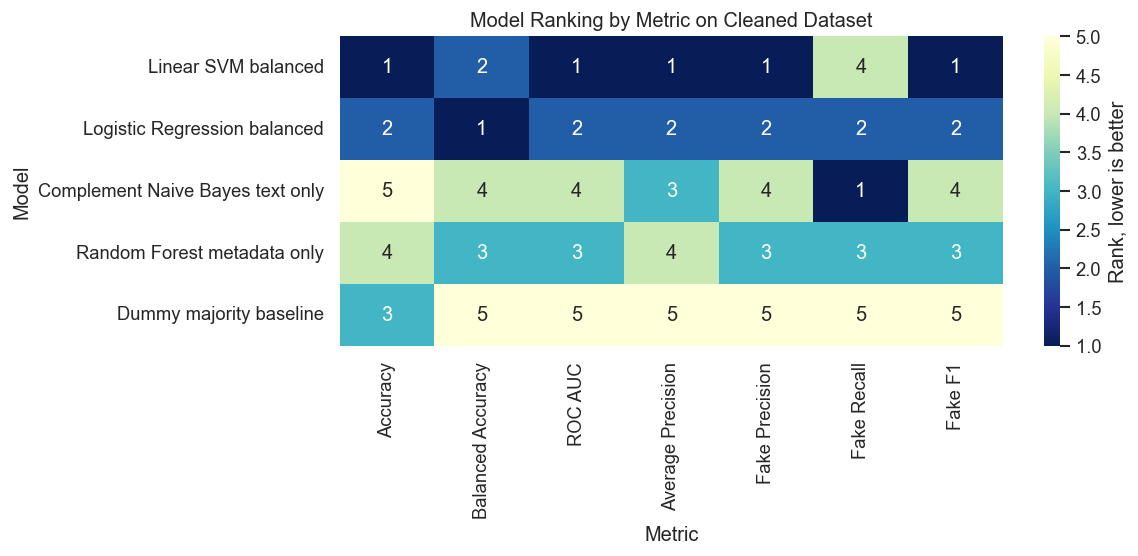

In [6]:
rank_df = cleaned_cv[['model'] + metric_cols].copy()
for metric in metric_cols:
    rank_df[metric_label(metric)] = higher_is_better_rank(rank_df[metric])
rank_display = rank_df[['model'] + [metric_label(m) for m in metric_cols]].copy()
display_and_save(rank_display, 'model_metric_rankings')

heatmap_df = rank_display.set_index('model')
plt.figure(figsize=(10, 4.8))
sns.heatmap(heatmap_df, annot=True, cmap='YlGnBu_r', cbar_kws={'label': 'Rank, lower is better'})
plt.title('Model Ranking by Metric on Cleaned Dataset')
plt.xlabel('Metric')
plt.ylabel('Model')
savefig('model_ranking_by_metric_heatmap')
plt.show()

## Metric Disagreement Interpretation

The table below compares each model's fake precision and fake recall. These two metrics often move in opposite directions on imbalanced classification tasks.

,model,average_precision_mean,precision_fake_mean,recall_fake_mean,f1_fake_mean,accuracy_mean
0,Linear SVM balanced,0.9140,0.8636,0.8395,0.8512,0.9858
1,Logistic Regression balanced,0.8810,0.6430,0.8903,0.7464,0.9706
2,Complement Naive Bayes text only,0.7387,0.2084,0.9215,0.3398,0.8261
3,Random Forest metadata only,0.7145,0.3469,0.8626,0.4947,0.9145
4,Dummy majority baseline,0.0484,0.0000,0.0000,0.0000,0.9516


Saved: imbalance_research_outputs\tables\precision_recall_metric_comparison.csv


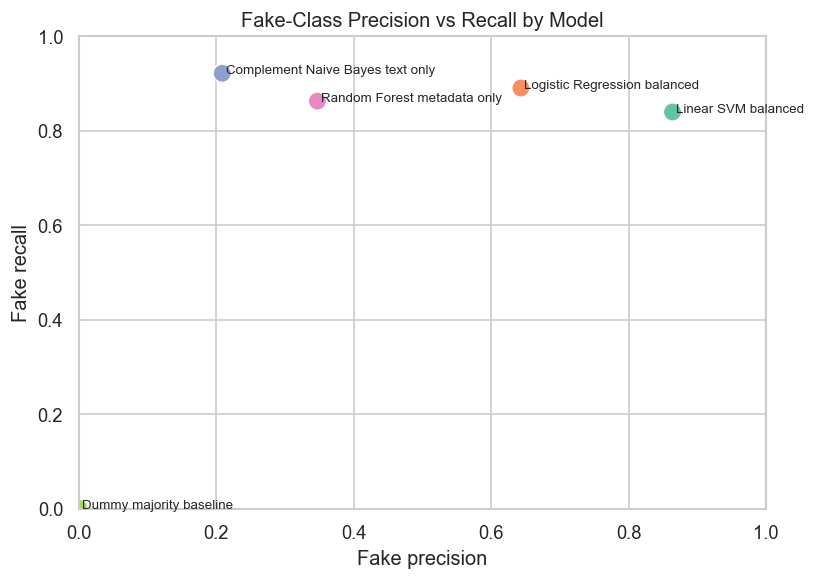

In [7]:
precision_recall_view = cleaned_cv[[
    'model', 'average_precision_mean', 'precision_fake_mean', 'recall_fake_mean', 'f1_fake_mean', 'accuracy_mean'
]].copy().sort_values('average_precision_mean', ascending=False)
display_and_save(precision_recall_view.round(4), 'precision_recall_metric_comparison')

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=precision_recall_view,
    x='precision_fake_mean',
    y='recall_fake_mean',
    hue='model',
    s=120,
)
for _, row in precision_recall_view.iterrows():
    plt.text(row['precision_fake_mean'] + 0.005, row['recall_fake_mean'], row['model'], fontsize=8)
plt.title('Fake-Class Precision vs Recall by Model')
plt.xlabel('Fake precision')
plt.ylabel('Fake recall')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend([], [], frameon=False)
savefig('fake_precision_vs_recall_by_model')
plt.show()

## Weighted vs Unweighted Linear Models

Class weighting is a direct way to respond to imbalance. This section compares weighted and unweighted linear models to show how class weighting changes fake precision and fake recall.

,model,average_precision_mean,precision_fake_mean,recall_fake_mean,f1_fake_mean,balanced_accuracy_mean
0,Linear SVM unweighted,0.9181,0.9301,0.7933,0.8559,0.8951
1,Linear SVM balanced,0.9140,0.8636,0.8395,0.8512,0.9164
2,Logistic Regression balanced,0.8810,0.6430,0.8903,0.7464,0.9325
3,Logistic Regression unweighted,0.8679,0.9292,0.6340,0.7527,0.8157


Saved: imbalance_research_outputs\tables\weighted_unweighted_cleaned_comparison.csv


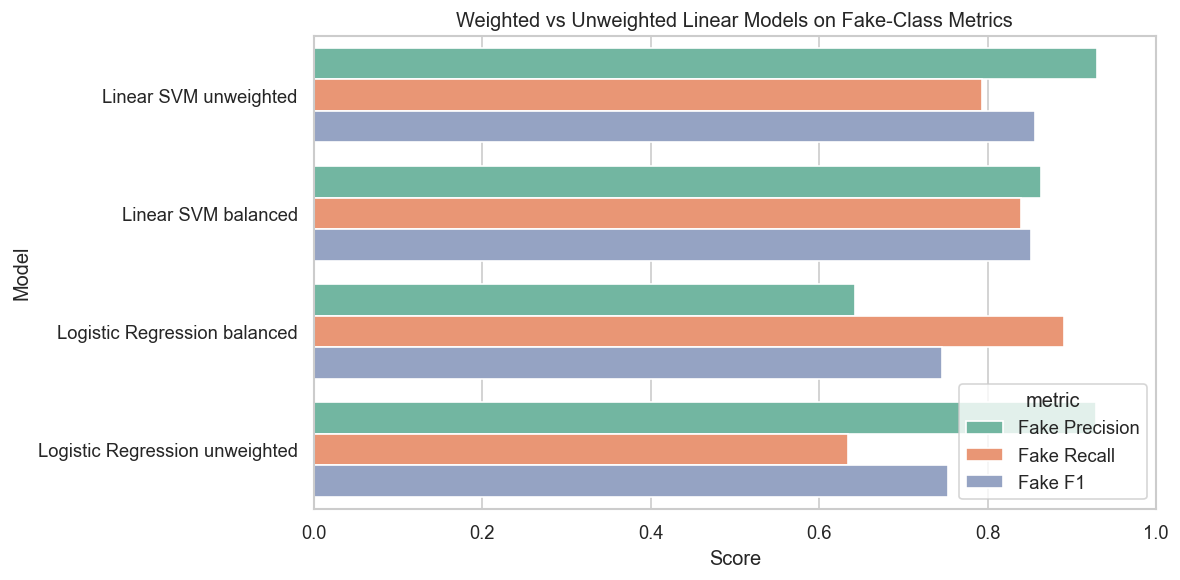

In [8]:
weighted_cleaned = weighted_results[weighted_results['dataset'].eq(PRIMARY_DATASET)].copy()
weighted_cleaned = weighted_cleaned[[
    'model', 'average_precision_mean', 'precision_fake_mean', 'recall_fake_mean', 'f1_fake_mean', 'balanced_accuracy_mean'
]].sort_values('average_precision_mean', ascending=False)
display_and_save(weighted_cleaned.round(4), 'weighted_unweighted_cleaned_comparison')

weighted_long = weighted_cleaned.melt(
    id_vars='model',
    value_vars=['precision_fake_mean', 'recall_fake_mean', 'f1_fake_mean'],
    var_name='metric',
    value_name='score'
)
weighted_long['metric'] = weighted_long['metric'].map({
    'precision_fake_mean': 'Fake Precision',
    'recall_fake_mean': 'Fake Recall',
    'f1_fake_mean': 'Fake F1',
})
plt.figure(figsize=(10, 5))
sns.barplot(data=weighted_long, x='score', y='model', hue='metric')
plt.title('Weighted vs Unweighted Linear Models on Fake-Class Metrics')
plt.xlabel('Score')
plt.ylabel('Model')
plt.xlim(0, 1)
savefig('weighted_vs_unweighted_fake_metrics')
plt.show()

## Threshold Sensitivity

The selected balanced Linear SVM produces a decision score. Changing the threshold changes the number of postings predicted as fake. This directly changes fake precision, fake recall, false positives, and false negatives.

,threshold,flagged_rate,true_positives,false_positives,false_negatives,fake_precision,fake_recall,fake_f1
0,-0.9649,0.1500,839,1843,27,0.3128,0.9688,0.4729
1,-0.7289,0.1000,823,965,43,0.4603,0.9503,0.6202
2,-0.5056,0.0750,807,534,59,0.6018,0.9319,0.7313
3,-0.0870,0.0500,742,152,124,0.8300,0.8568,0.8432
4,0.0000,0.0471,727,115,139,0.8634,0.8395,0.8513
5,0.2374,0.0400,670,46,196,0.9358,0.7737,0.8470
6,0.6742,0.0300,527,10,339,0.9814,0.6085,0.7512


Saved: imbalance_research_outputs\tables\threshold_sensitivity_summary.csv


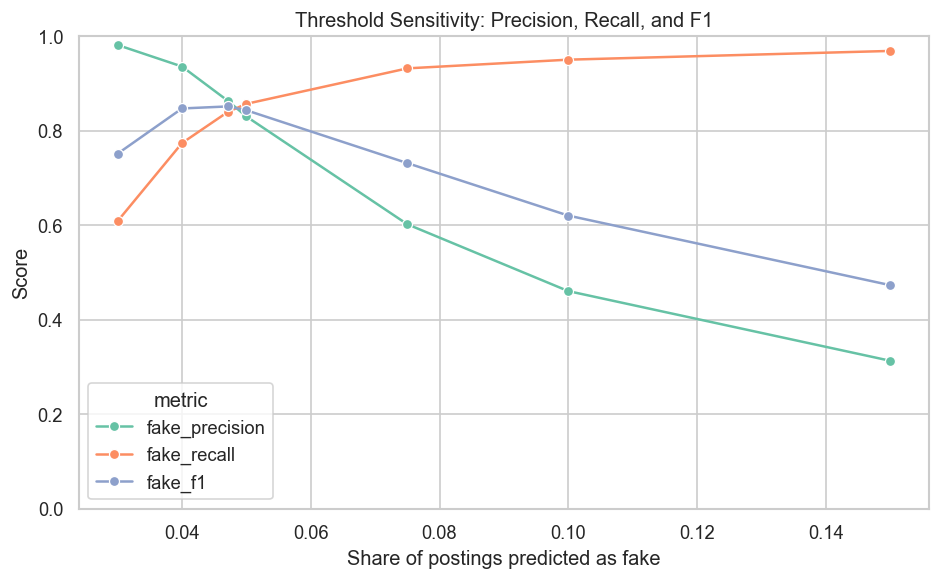

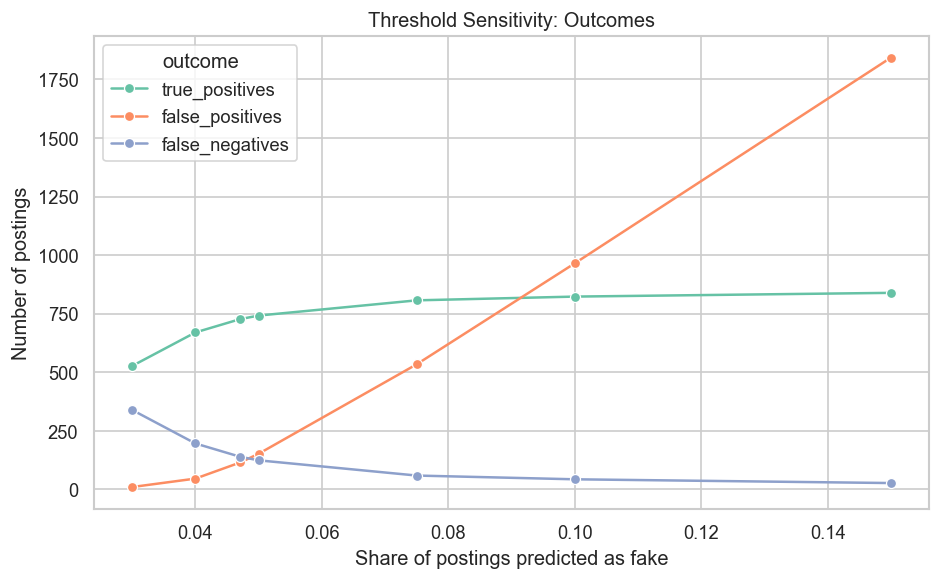

In [9]:
threshold_view = threshold_results[[
    'threshold', 'flagged_rate', 'true_positives', 'false_positives', 'false_negatives',
    'fake_precision', 'fake_recall', 'fake_f1'
]].copy().sort_values('threshold')
display_and_save(threshold_view.round(4), 'threshold_sensitivity_summary')

threshold_long = threshold_view.melt(
    id_vars=['threshold', 'flagged_rate'],
    value_vars=['fake_precision', 'fake_recall', 'fake_f1'],
    var_name='metric',
    value_name='score'
)
plt.figure(figsize=(8, 5))
sns.lineplot(data=threshold_long, x='flagged_rate', y='score', hue='metric', marker='o')
plt.title('Threshold Sensitivity: Precision, Recall, and F1')
plt.xlabel('Share of postings predicted as fake')
plt.ylabel('Score')
plt.ylim(0, 1)
savefig('threshold_sensitivity_precision_recall_f1')
plt.show()

count_long = threshold_view.melt(
    id_vars=['threshold', 'flagged_rate'],
    value_vars=['true_positives', 'false_positives', 'false_negatives'],
    var_name='outcome',
    value_name='count'
)
plt.figure(figsize=(8, 5))
sns.lineplot(data=count_long, x='flagged_rate', y='count', hue='outcome', marker='o')
plt.title('Threshold Sensitivity: Outcomes')
plt.xlabel('Share of postings predicted as fake')
plt.ylabel('Number of postings')
savefig('threshold_sensitivity_outcomes')
plt.show()

## Separate Threshold Metric Views

The combined threshold plot is useful for seeing precision, recall, and F1 together, but each metric answers a different question. This section separates the three metrics before comparing them.

- **Fake precision:** Of the postings predicted as fake, how many were actually fake?
- **Fake recall:** Of the actual fake postings, how many were detected?
- **Fake F1:** What is the balance between fake precision and fake recall?

Separating the plots makes the tradeoff easier to interpret.

,threshold,flagged_rate,fake_precision,fake_recall,fake_f1,true_positives,false_positives,false_negatives
0,-0.9649,0.1500,0.3128,0.9688,0.4729,839,1843,27
1,-0.7289,0.1000,0.4603,0.9503,0.6202,823,965,43
2,-0.5056,0.0750,0.6018,0.9319,0.7313,807,534,59
3,-0.0870,0.0500,0.8300,0.8568,0.8432,742,152,124
4,0.0000,0.0471,0.8634,0.8395,0.8513,727,115,139
5,0.2374,0.0400,0.9358,0.7737,0.8470,670,46,196
6,0.6742,0.0300,0.9814,0.6085,0.7512,527,10,339


Saved: imbalance_research_outputs\tables\separate_threshold_metric_values.csv


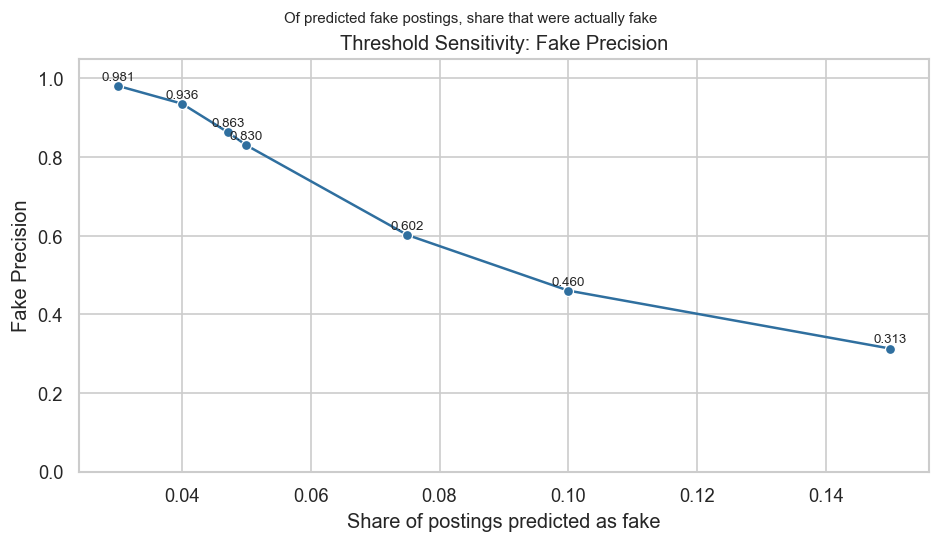

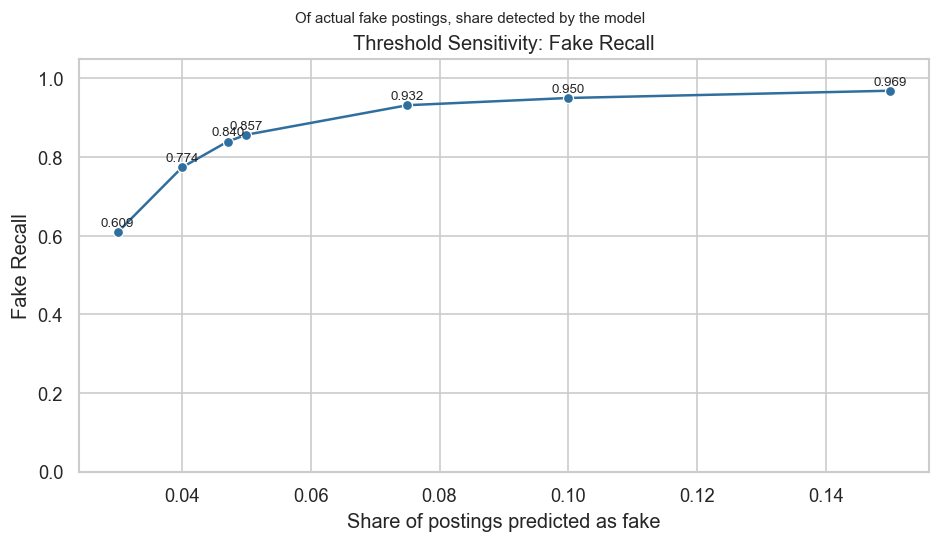

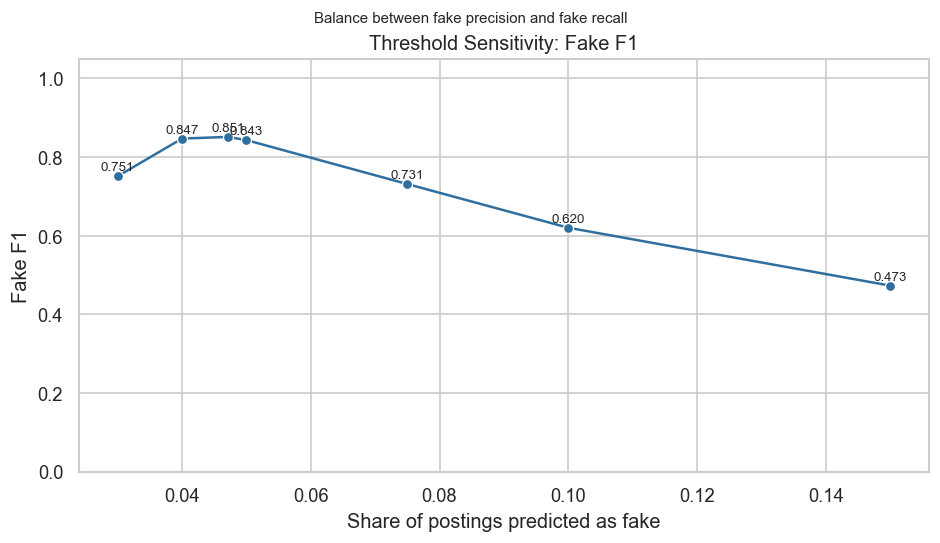

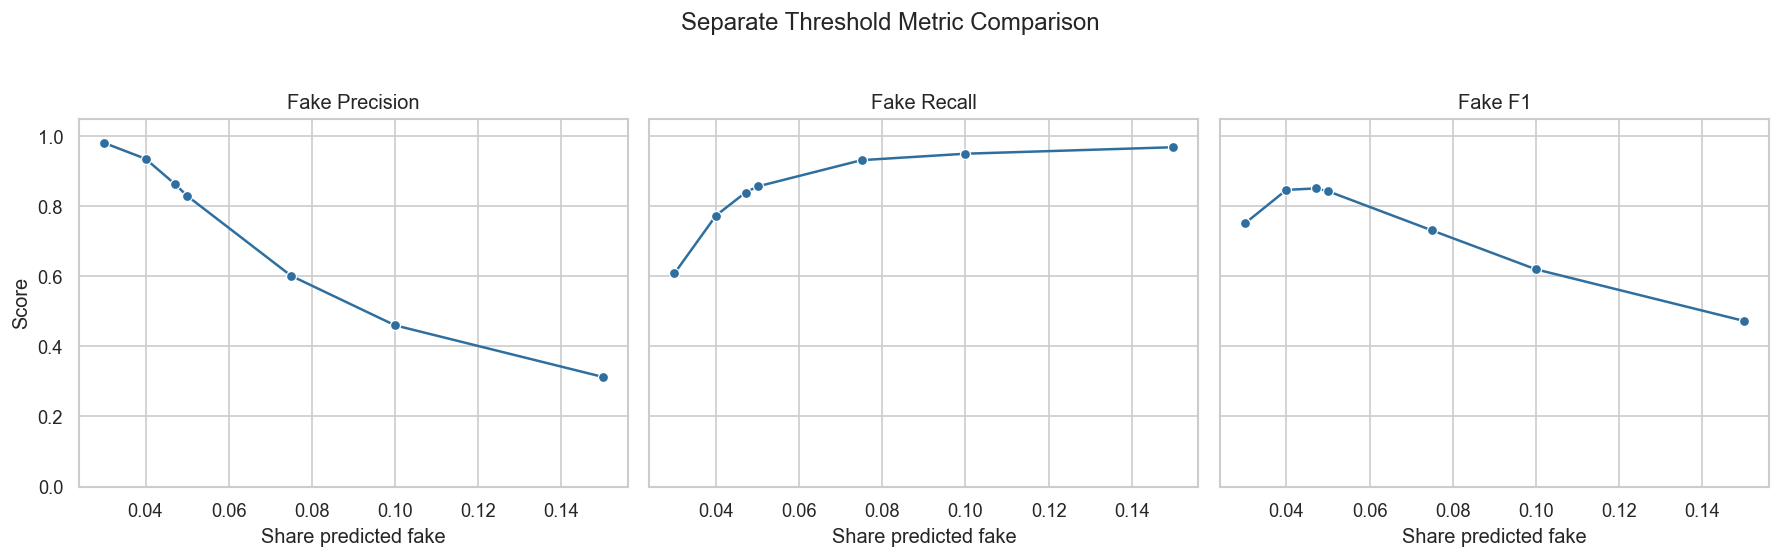

In [10]:
# Separate threshold plots for fake precision, fake recall, and fake F1
separate_threshold_metrics = threshold_view[[
    'threshold', 'flagged_rate', 'fake_precision', 'fake_recall', 'fake_f1',
    'true_positives', 'false_positives', 'false_negatives'
]].copy().round(4)
display_and_save(separate_threshold_metrics, 'separate_threshold_metric_values')

metric_details = [
    ('fake_precision', 'Fake Precision', 'Of predicted fake postings, share that were actually fake'),
    ('fake_recall', 'Fake Recall', 'Of actual fake postings, share detected by the model'),
    ('fake_f1', 'Fake F1', 'Balance between fake precision and fake recall'),
]

for metric, label, subtitle in metric_details:
    plt.figure(figsize=(8, 4.8))
    sns.lineplot(data=threshold_view, x='flagged_rate', y=metric, marker='o', color='#2f6f9f')
    for _, row in threshold_view.iterrows():
        plt.text(row['flagged_rate'], row[metric] + 0.015, f"{row[metric]:.3f}", ha='center', fontsize=8)
    plt.title(f'Threshold Sensitivity: {label}')
    plt.suptitle(subtitle, y=0.94, fontsize=9)
    plt.xlabel('Share of postings predicted as fake')
    plt.ylabel(label)
    plt.ylim(0, 1.05)
    savefig(f'threshold_sensitivity_{metric}_separate')
    plt.show()

# Small-multiple comparison keeps the same x-axis but gives each metric its own panel.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
for ax, (metric, label, subtitle) in zip(axes, metric_details):
    sns.lineplot(data=threshold_view, x='flagged_rate', y=metric, marker='o', ax=ax, color='#2f6f9f')
    ax.set_title(label)
    ax.set_xlabel('Share predicted fake')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
fig.suptitle('Separate Threshold Metric Comparison', y=1.03)
savefig('threshold_sensitivity_separate_metric_panels')
plt.show()

## Interpreting the Separate Threshold Metrics

The separated plots show three different patterns:

1. **Fake precision decreases** as the model predicts a larger share of postings as fake. This happens because the model begins including more real postings in the predicted-fake group.
2. **Fake recall increases** as the model predicts a larger share of postings as fake. This happens because more actual fake postings are captured.
3. **Fake F1 peaks near the middle** because F1 is highest when precision and recall are more balanced.

The separate plots make it clearer that precision and recall move in opposite directions. F1 is not a separate type of error; it is a combined score derived from precision and recall.

## Simple Cost Sensitivity Analysis

This section treats false negatives and false positives as having different costs. The calculation is not a claim about real costs; it is a sensitivity analysis showing how the preferred threshold changes when false negatives are weighted more heavily than false positives.

,false_positive_cost,false_negative_cost,best_threshold,best_flagged_rate,false_positives,false_negatives,fake_precision,fake_recall,total_cost
0,1,1,0.2374,0.0400,46,196,0.9358,0.7737,242.0
1,1,2,0.0000,0.0471,115,139,0.8634,0.8395,393.0
2,1,5,-0.0870,0.0500,152,124,0.8300,0.8568,772.0
3,1,10,-0.5056,0.0750,534,59,0.6018,0.9319,1124.0
4,1,20,-0.5056,0.0750,534,59,0.6018,0.9319,1714.0


Saved: imbalance_research_outputs\tables\cost_sensitivity_threshold_selection.csv


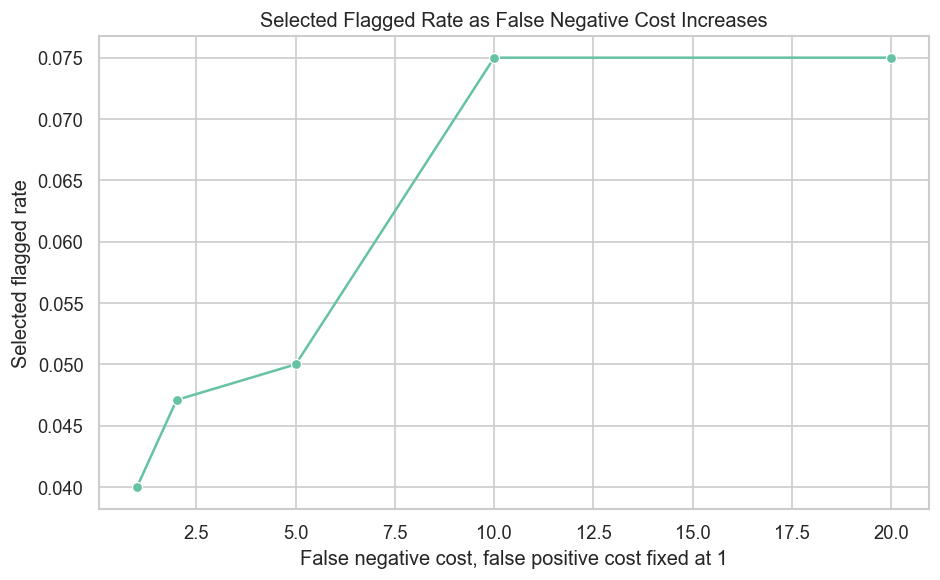

In [11]:
cost_rows = []
false_negative_costs = [1, 2, 5, 10, 20]
false_positive_cost = 1
for fn_cost in false_negative_costs:
    temp = threshold_view.copy()
    temp['false_positive_cost'] = temp['false_positives'] * false_positive_cost
    temp['false_negative_cost'] = temp['false_negatives'] * fn_cost
    temp['total_cost'] = temp['false_positive_cost'] + temp['false_negative_cost']
    best = temp.sort_values('total_cost').iloc[0]
    cost_rows.append({
        'false_positive_cost': false_positive_cost,
        'false_negative_cost': fn_cost,
        'best_threshold': best['threshold'],
        'best_flagged_rate': best['flagged_rate'],
        'false_positives': int(best['false_positives']),
        'false_negatives': int(best['false_negatives']),
        'fake_precision': best['fake_precision'],
        'fake_recall': best['fake_recall'],
        'total_cost': best['total_cost'],
    })

cost_sensitivity = pd.DataFrame(cost_rows)
display_and_save(cost_sensitivity.round(4), 'cost_sensitivity_threshold_selection')

plt.figure(figsize=(8, 5))
sns.lineplot(data=cost_sensitivity, x='false_negative_cost', y='best_flagged_rate', marker='o')
plt.title('Selected Flagged Rate as False Negative Cost Increases')
plt.xlabel('False negative cost, false positive cost fixed at 1')
plt.ylabel('Selected flagged rate')
savefig('cost_sensitivity_selected_flagged_rate')
plt.show()

## Error Patterns Related to Imbalance

The previous project already produced detailed error-analysis outputs. Here, the focus is on how those errors relate to imbalance and decision-making.

,prediction_group,count,model_score_for_fake,has_company_logo,has_company_profile,description_chars_for_analysis,requirements_chars_for_analysis
0,True positive,727,0.938,0.338,0.331,1154.351,441.301
1,False negative,139,-0.545,0.266,0.273,1157.367,470.885
2,False positive,115,0.289,0.183,0.165,981.330,404.330
3,True negative,16899,-1.746,0.823,0.845,1222.852,598.780


Saved: imbalance_research_outputs\tables\compact_error_group_summary.csv


,feature,feature_value,row_count,false_positive_rate_among_real,false_negative_rate_among_fake
0,has_company_logo,0,3660,0.0305,0.1750
1,has_company_logo,1,14220,0.0015,0.1307
2,has_questions,0,9088,0.0092,0.1445
3,has_questions,1,8792,0.0043,0.2000
4,has_salary_range,0,15012,0.0054,0.1493
5,has_salary_range,1,2868,0.0144,0.1928
6,has_benefits,0,7212,0.0086,0.1786
7,has_benefits,1,10668,0.0055,0.1474
8,has_company_profile,0,3308,0.0353,0.1721
9,has_company_profile,1,14572,0.0013,0.1362


Saved: imbalance_research_outputs\tables\compact_binary_feature_error_rates.csv


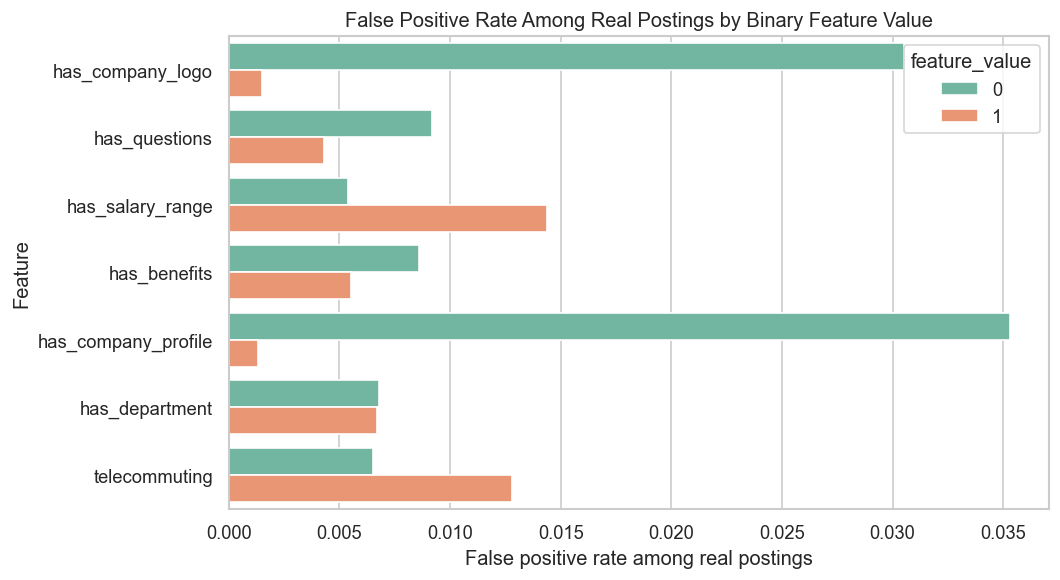

In [12]:
error_group_compact = error_group_summary[[
    'prediction_group', 'count', 'model_score_for_fake', 'has_company_logo',
    'has_company_profile', 'description_chars_for_analysis', 'requirements_chars_for_analysis'
]].copy()
display_and_save(error_group_compact.round(4), 'compact_error_group_summary')

binary_error_compact = binary_error_rates[[
    'feature', 'feature_value', 'row_count',
    'false_positive_rate_among_real', 'false_negative_rate_among_fake'
]].copy()
display_and_save(binary_error_compact.round(4), 'compact_binary_feature_error_rates')

plt.figure(figsize=(9, 5))
sns.barplot(
    data=binary_error_compact,
    x='false_positive_rate_among_real',
    y='feature',
    hue='feature_value',
)
plt.title('False Positive Rate Among Real Postings by Binary Feature Value')
plt.xlabel('False positive rate among real postings')
plt.ylabel('Feature')
savefig('false_positive_rate_by_binary_feature')
plt.show()

## Research Summary

The analyses in this notebook support three conclusions:

1. **Accuracy is insufficient** because the majority-class baseline has high accuracy while detecting no fake postings.
2. **Model selection depends on the metric.** Metrics focused on fake precision, fake recall, fake F1, and average precision emphasize different model behavior.
3. **Threshold choice changes the operating behavior of the same model.** Lower thresholds increase fake recall and false positives; higher thresholds increase fake precision and false negatives.

This means the imbalance problem is not only a data distribution issue. It affects how model performance is measured, which model is selected, and how the selected model behaves at different thresholds.